# 01 — Exploration des données & harmonisation des labels (M1)

**Phase ML :** acquisition, analyse exploratoire (EDA), harmonisation cross-dataset.
**Contribution visée :** prépare C1 (generalization gap) — voir `PLAN.md` M1.
**Skill associé :** `.claude/skills/medical-imaging-data`.

## Objectif scientifique

Le cœur d'un benchmark cross-dataset n'est pas de charger des pixels, c'est de rendre
les labels **comparables** entre datasets aux vocabulaires différents (CheXpert,
NIH, PadChest, VinDr). Ce notebook :

1. charge le manifest unifié construit par `scripts/build_manifest.py` ;
2. audite sa qualité (complétude, équilibre des classes, démographie) ;
3. vérifie l'**intégrité** (aucune fuite patient inter-split, valeurs de labels valides) ;
4. expose la **table d'harmonisation** et le sous-ensemble de pathologies communes —
   l'artefact central sur lequel C1 sera évalué.

> **Rigueur :** on ne regarde JAMAIS le split `test` au-delà de statistiques agrégées de
> sanity-check. Le protocole d'évaluation est figé avant de regarder les résultats.

## 0. Configuration

In [11]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from radgap.data import (
    LABEL_COLUMNS,
    canonical_pathologies,
    load_manifest,
    validate_manifest,
)

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_ROOT = Path(os.environ.get("RADGAP_DATA_ROOT", "/mnt/z/Data/radgap"))
MANIFEST = DATA_ROOT / "manifests" / "unified.parquet"

## 1. Chargement du manifest unifié

Si le manifest n'existe pas encore, lancer d'abord :
```bash
uv run python scripts/download_aimi.py --dataset chexpert_plus
uv run python scripts/download_nih.py
uv run python scripts/build_manifest.py
```

In [12]:
if MANIFEST.exists():
    df = load_manifest(MANIFEST)
    print(f"Manifest : {len(df):,} images, {df['dataset'].nunique()} datasets")
    display(df.head())
else:
    print(f"⚠️ Manifest absent ({MANIFEST}). Voir les commandes ci-dessus.")
    df = None

Manifest : 223,462 images, 1 datasets


,image_path,dataset,patient_id,split,view,sex,age,race,label_cardiomegaly,label_edema,label_consolidation,label_atelectasis,label_pleural_effusion,label_pneumothorax,label_pneumonia,label_lung_opacity,label_fracture,label_no_finding
0,train/patient19324/study2/view1_frontal.jpg,chexpert_plus,chexpert_plus_patient19324,train,AP,M,72.0,White,NaN,0.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN
1,train/patient19324/study3/view1_frontal.jpg,chexpert_plus,chexpert_plus_patient19324,train,AP,M,72.0,White,NaN,NaN,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN
2,train/patient19852/study1/view2_lateral.jpg,chexpert_plus,chexpert_plus_patient19852,train,LATERAL,F,55.0,White,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,1.0
3,train/patient19852/study1/view1_frontal.jpg,chexpert_plus,chexpert_plus_patient19852,train,PA,F,55.0,White,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,1.0
4,train/patient19958/study1/view1_frontal.jpg,chexpert_plus,chexpert_plus_patient19958,train,AP,M,58.0,Asian,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


## 2. Intégrité (DoD M1)

Checks automatiques : schéma complet, 0 fuite patient inter-split, labels dans {0,1,NaN}.

In [13]:
if df is not None:
    problems = validate_manifest(df)
    print("✅ Manifest valide" if not problems else "❌ Problèmes :")
    for p in problems:
        print("  -", p)

✅ Manifest valide


## 3. Répartition par dataset et par split

On vérifie que chaque dataset a bien des images, et que le split par patient est cohérent.

split,test,train,val
dataset,,,
chexpert_plus,22272,179102,22088


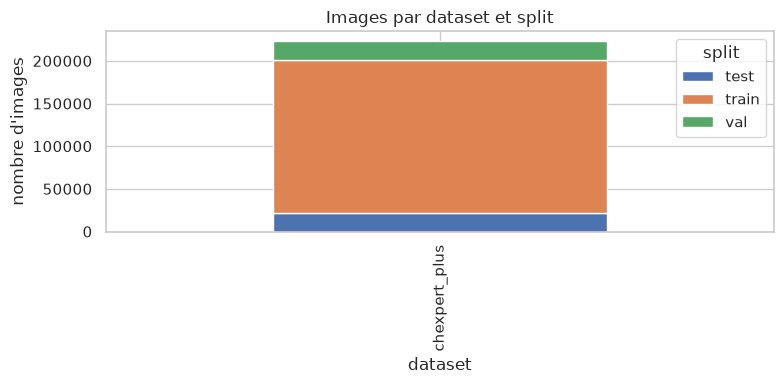

In [14]:
if df is not None:
    pivot = df.pivot_table(index="dataset", columns="split", values="image_path", aggfunc="count", fill_value=0)
    display(pivot)
    pivot.plot(kind="bar", stacked=True, figsize=(8, 4), title="Images par dataset et split")
    plt.ylabel("nombre d'images")
    plt.tight_layout()
    plt.show()

## 4. Prévalence des pathologies (déséquilibre de classes)

Les pathologies CXR sont rares et déséquilibrées : c'est pourquoi l'AUROC (insensible au
seuil et au déséquilibre) est la métrique primaire, pas l'accuracy.

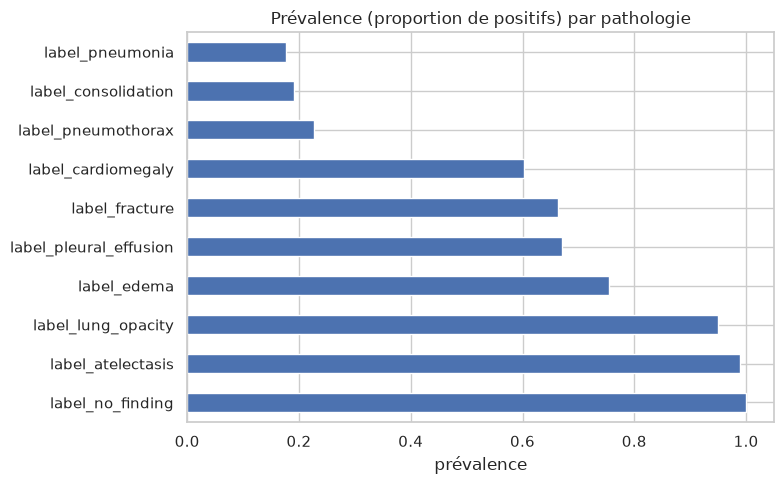

,prévalence
label_no_finding,1.000000
label_atelectasis,0.989461
label_lung_opacity,0.950065
label_edema,0.754456
label_pleural_effusion,0.670319
label_fracture,0.663213
label_cardiomegaly,0.603448
label_pneumothorax,0.226523
label_consolidation,0.190886
label_pneumonia,0.176024


In [15]:
if df is not None:
    prevalence = (
        df[LABEL_COLUMNS]
        .apply(lambda c: c.mean())  # moyenne en ignorant les NaN
        .sort_values(ascending=False)
    )
    prevalence.plot(kind="barh", figsize=(8, 5), title="Prévalence (proportion de positifs) par pathologie")
    plt.xlabel("prévalence")
    plt.tight_layout()
    plt.show()
    display(prevalence.to_frame("prévalence"))

## 5. Taux de labels manquants (NaN ≠ négatif)

Différents datasets labellisent différentes pathologies. Les NaN sont **masqués** dans la
loss et les métriques — jamais comptés comme négatifs (cela corromprait silencieusement
l'AUROC).

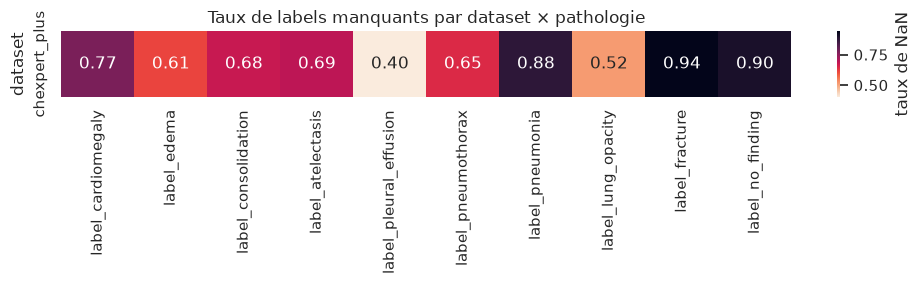

In [16]:
if df is not None:
    missing = df.groupby("dataset")[LABEL_COLUMNS].apply(lambda g: g.isna().mean())
    plt.figure(figsize=(10, 3))
    sns.heatmap(missing, annot=True, fmt=".2f", cmap="rocket_r", cbar_kws={"label": "taux de NaN"})
    plt.title("Taux de labels manquants par dataset × pathologie")
    plt.tight_layout()
    plt.show()

## 6. Démographie (préparation de l'audit d'équité C3)

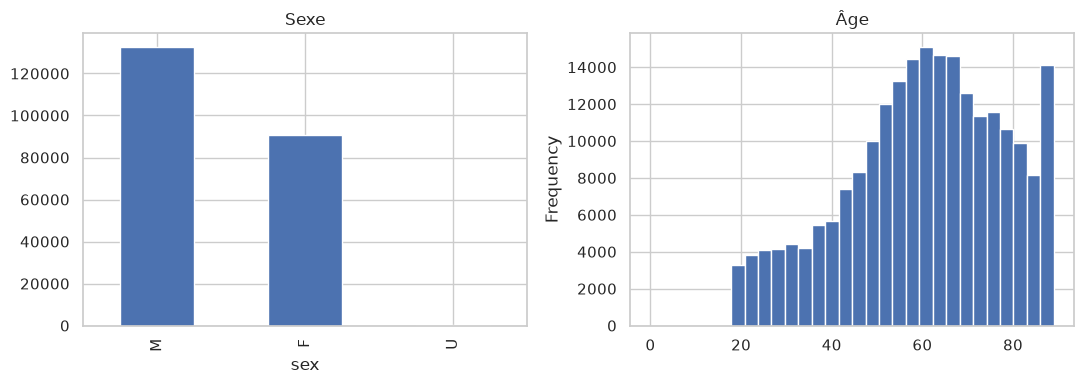

In [17]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    df["sex"].value_counts().plot(kind="bar", ax=axes[0], title="Sexe")
    df["age"].dropna().plot(kind="hist", bins=30, ax=axes[1], title="Âge")
    plt.tight_layout()
    plt.show()

## 7. La table d'harmonisation — sous-ensembles de pathologies communes

C1 (generalization gap) est évalué UNIQUEMENT sur les pathologies partagées entre
CheXpert Plus (source) et chaque dataset OOD (cible).

In [18]:
for target in ("nih_cxr14", "padchest", "vindr_cxr"):
    shared = canonical_pathologies("chexpert_plus", target)
    print(f"chexpert_plus ∩ {target} ({len(shared)}) : {shared}")

chexpert_plus ∩ nih_cxr14 (9) : ['Cardiomegaly', 'Edema', 'Consolidation', 'Atelectasis', 'Pleural Effusion', 'Pneumothorax', 'Pneumonia', 'Lung Opacity', 'No Finding']
chexpert_plus ∩ padchest (10) : ['Cardiomegaly', 'Edema', 'Consolidation', 'Atelectasis', 'Pleural Effusion', 'Pneumothorax', 'Pneumonia', 'Lung Opacity', 'Fracture', 'No Finding']
chexpert_plus ∩ vindr_cxr (9) : ['Cardiomegaly', 'Consolidation', 'Atelectasis', 'Pleural Effusion', 'Pneumothorax', 'Pneumonia', 'Lung Opacity', 'Fracture', 'No Finding']


## Conclusion & prochaine étape

- Le manifest unifié relie chaque image à ses labels canoniques, sa démographie et son split.
- Les sous-ensembles communs sont figés : ils définissent le terrain d'évaluation de C1.
- **Suite (M3) :** `02_preprocessing_and_augmentation` puis `03_embeddings_and_linear_probing`.